# Transformations and Multiplicative Seasonality

The lecture distinguishes two seasonal patterns:

- Additive, or constant, seasonality: the seasonal swing is roughly the same size over time.
- Multiplicative, or increasing, seasonality: the seasonal swing grows as the level of the series grows.

When seasonal swing grows with the level, modeling a transformed response, especially $log(y_t)$, can stabilize the pattern. This notebook uses a hotel-room teaching dataset in the same style as the software notes.

A compact way to describe the lecture's transformation family is the Box-Cox-style idea

$$y_t^* = y_t^\lambda.$$

Common choices include $\sqrt{y_t}$, $\log(y_t)$, and $1/y_t$. As $\lambda$ approaches 0, the transformed scale approaches $\log(y_t)$.

In [1]:
from lite_setup import ensure_packages
await ensure_packages()

Running outside JupyterLite; assuming packages are already installed.


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.formula.api as smf
from statsmodels.stats.stattools import durbin_watson
from checks import check_columns, check_no_missing

plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.grid'] = True
hotel = pd.read_csv(Path('data/hotel_rooms.csv'))
print(check_columns(hotel, ['Year', 'Month', 'MonthNumber', 'Time', 'Rooms']))
hotel.head()

Ready: found Year, Month, MonthNumber, Time, Rooms


,Year,Month,MonthNumber,Time,Rooms
0,1,Jan,1,1,96.4
1,1,Feb,2,2,103.1
2,1,Mar,3,3,115.8
3,1,Apr,4,4,122.5
4,1,May,5,5,130.2


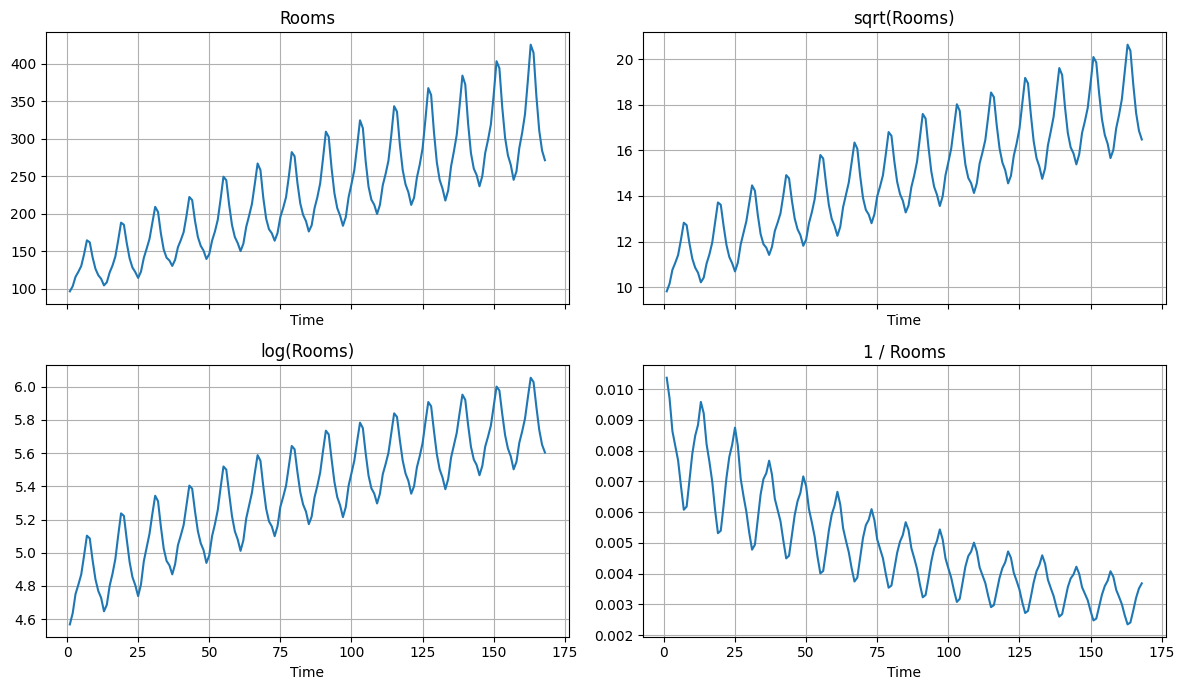

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
series = [
    ('Rooms', hotel['Rooms']),
    ('sqrt(Rooms)', np.sqrt(hotel['Rooms'])),
    ('log(Rooms)', np.log(hotel['Rooms'])),
    ('1 / Rooms', 1 / hotel['Rooms']),
]
for ax, (title, values) in zip(axes.ravel(), series):
    ax.plot(hotel['Time'], values)
    ax.set_title(title)
    ax.set_xlabel('Time')
plt.tight_layout()

The raw series has an increasing level and the seasonal highs and lows spread farther apart as time increases. The log scale makes multiplicative seasonal effects closer to additive effects on the transformed scale.

In the fitted monthly dummy model below, December is used as the baseline month to mirror the lecture notation. Each displayed monthly coefficient is interpreted relative to December, after accounting for the time trend.

In [4]:
hotel['LogRooms'] = np.log(hotel['Rooms'])
log_model = smf.ols('LogRooms ~ Time + C(Month, Treatment(reference="Dec"))', data=hotel).fit()
print(log_model.summary().tables[1])

                                                  coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------
Intercept                                       4.7025      0.012    389.579      0.000       4.679       4.726
C(Month, Treatment(reference="Dec"))[T.Apr]     0.1528      0.015     10.152      0.000       0.123       0.182
C(Month, Treatment(reference="Dec"))[T.Aug]     0.4211      0.015     27.998      0.000       0.391       0.451
C(Month, Treatment(reference="Dec"))[T.Feb]    -0.0242      0.015     -1.610      0.109      -0.054       0.005
C(Month, Treatment(reference="Dec"))[T.Jan]    -0.0741      0.015     -4.919      0.000      -0.104      -0.044
C(Month, Treatment(reference="Dec"))[T.Jul]     0.4512      0.015     29.995      0.000       0.421       0.481
C(Month, Treatment(reference="Dec"))[T.Jun]     0.3384      0.015     22.498      0.000       0.309     

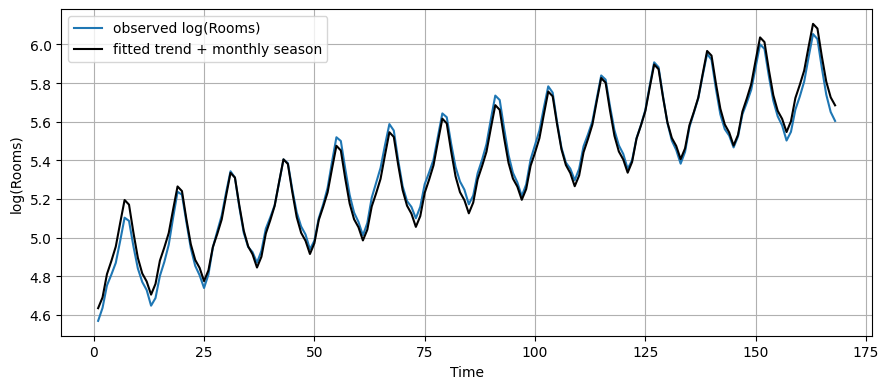

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(hotel['Time'], hotel['LogRooms'], label='observed log(Rooms)')
ax.plot(hotel['Time'], log_model.fittedvalues, color='black', label='fitted trend + monthly season')
ax.set_xlabel('Time')
ax.set_ylabel('log(Rooms)')
ax.legend()
plt.tight_layout()

To forecast on the original scale, first predict on the log scale and then exponentiate. A simple exponentiated mean forecast is easy to explain, but remember that exact unbiased back-transformation requires additional care. For this course workflow, focus on selecting the transformation, fitting the transformed regression, and clearly stating the scale of each result.

In [6]:
future_months = pd.DataFrame({
    'Time': np.arange(169, 181),
    'Month': ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'],
})
log_pred = log_model.get_prediction(future_months).summary_frame(alpha=0.05)
forecast = future_months.copy()
forecast['mean_log'] = log_pred['mean']
forecast['forecast_rooms_simple'] = np.exp(log_pred['mean'])
forecast[['Time', 'Month', 'mean_log', 'forecast_rooms_simple']].round(2)

,Time,Month,mean_log,forecast_rooms_simple
0,169,Jan,5.62,274.97
1,170,Feb,5.67,290.71
2,171,Mar,5.79,327.91
3,172,Apr,5.86,351.08
4,173,May,5.94,378.28
5,174,Jun,6.06,427.69
6,175,Jul,6.18,481.53
7,176,Aug,6.15,470.00
8,177,Sep,6.01,406.53
9,178,Oct,5.88,356.99


Transfer question: in a business report, how would you explain the difference between additive and multiplicative seasonality without using formulas?